In [135]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report,roc_curve,roc_auc_score
from imblearn.over_sampling import SMOTE

In [136]:
df=pd.read_csv("Telco-Customer-Churn.csv")

In [137]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [138]:
df.shape

(7043, 21)

In [139]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [140]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [141]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [142]:
df.duplicated().sum()

np.int64(0)

In [143]:
df.drop(['customerID'],axis=1,inplace=True)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [144]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [145]:
counts = df['Churn'].value_counts()

print(f"Class Imbalance Ratio: {counts['No'] / counts['Yes']:.2f}:1")

Class Imbalance Ratio: 2.77:1


<Axes: xlabel='Churn', ylabel='count'>

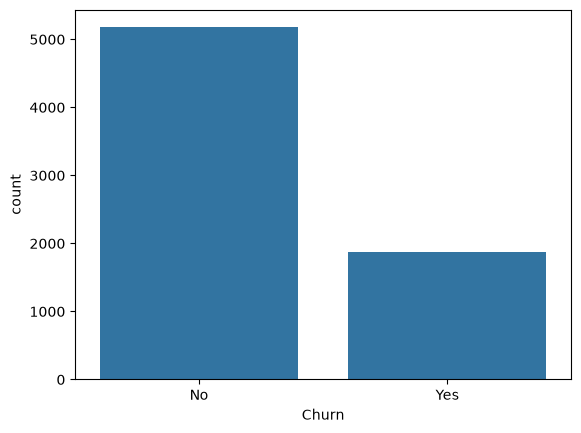

In [146]:
sns.countplot(data=df,x='Churn')

In [147]:
df["TotalCharges"] = df["TotalCharges"].replace({" " : "0.0"}).astype(float)

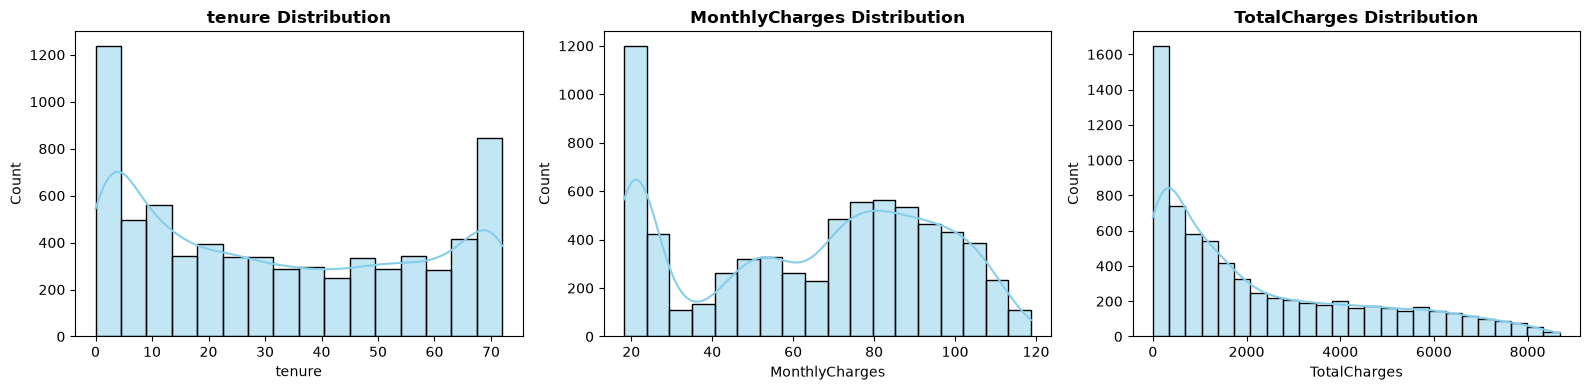

In [148]:
fig , axes = plt.subplots(1, 3, figsize=(16,4))

for idx, col in enumerate(["tenure", "MonthlyCharges","TotalCharges"]):
    sns.histplot(df[col], kde=True, ax=axes[idx], color='skyblue')
    axes[idx].set_title(f'{col} Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()

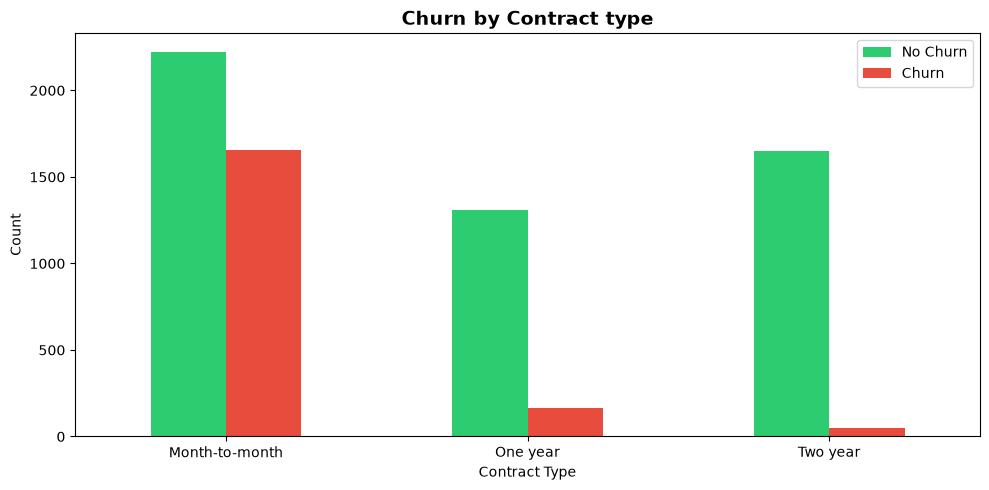

In [149]:
fig, ax = plt.subplots(1,1, figsize=(10, 5))
contract_churn = df.groupby(['Contract', 'Churn']).size().unstack(fill_value=0)
contract_churn.plot(kind='bar', stacked=False, ax=ax, color=['#2ecc71', '#e74c3c'])
ax.set_title('Churn by Contract type', fontsize=14, fontweight='bold')
ax.set_xlabel('Contract Type')
ax.set_ylabel('Count')
ax.legend(['No Churn', 'Churn'])
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()

In [150]:
binary_cols=['Partner','Dependents','PhoneService','PaperlessBilling','Churn']
for col in binary_cols:
    df[col]=df[col].map({'Yes':1,'No':0})

df['gender']=df['gender'].map({'Male':1,'Female':0})

categorical_cols = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
]
encoders={}
for col in categorical_cols:
    encoder=LabelEncoder()
    df[col]=encoder.fit_transform(df[col])
    encoders[col]=encoder

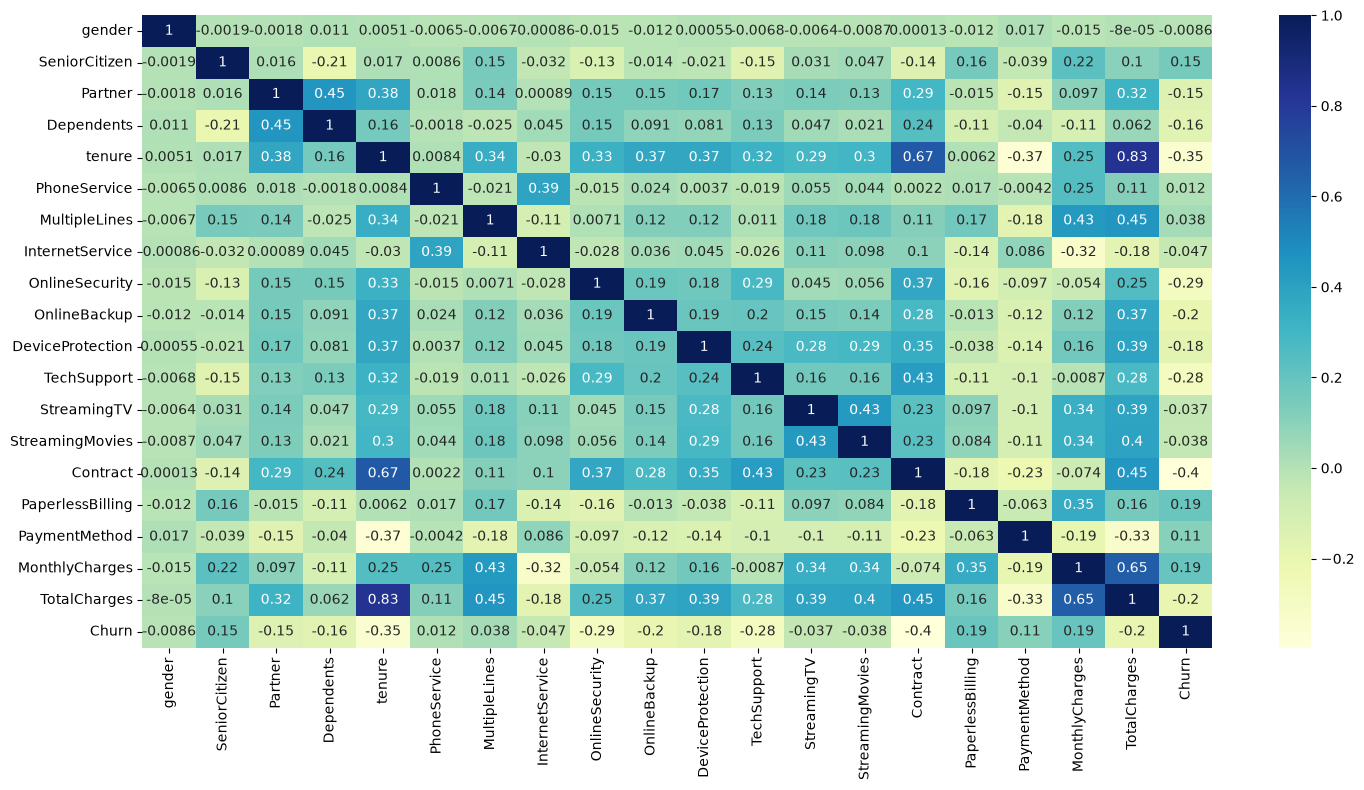

In [151]:
plt.figure(figsize=(15,8))
sns.heatmap(df.corr(),annot=True,cmap="YlGnBu")
plt.tight_layout()

In [152]:
X=df.drop(['Churn'],axis=1)
y=df['Churn']

x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y)

In [153]:
scaler=StandardScaler()
x_train_s=scaler.fit_transform(x_train)
x_test_s=scaler.transform(x_test)

In [154]:
smote=SMOTE(random_state=42)
x_train_balanced,y_train_balanced=smote.fit_resample(x_train,y_train)
x_train_balanced_s,y_train_balanced_s=smote.fit_resample(x_train,y_train)

In [155]:
y_train.value_counts()

Churn
0    4139
1    1495
Name: count, dtype: int64

In [156]:
y_train_balanced.value_counts()

Churn
1    4139
0    4139
Name: count, dtype: int64

In [157]:
logreg=LogisticRegression(max_iter=5000)
logreg.fit(x_train_balanced_s,y_train_balanced_s)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",5000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [158]:
y_pred = logreg.predict(x_test_s)
y_train_pred = logreg.predict(x_train_s)

c:\Users\neha2\OneDrive\Documents\Programming\ML_Projects\Customer Churn Predictor\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\neha2\OneDrive\Documents\Programming\ML_Projects\Customer Churn Predictor\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [159]:
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_pred)
print('Training Accuracy', train_acc)
print('Test Accuracy', test_acc)

Training Accuracy 0.43858714944976923
Test Accuracy 0.44002838892831797


In [160]:
print(f"Precison:{precision_score(y_test,y_pred)}")
print(f"Recall:{recall_score(y_test,y_pred)}")
print(f"F1 Score:{f1_score(y_test,y_pred)}")

Precison:0.3165340406719717
Recall:0.9572192513368984
F1 Score:0.4757475083056478


Text(0.5, 36.38563368055554, 'Predicted')

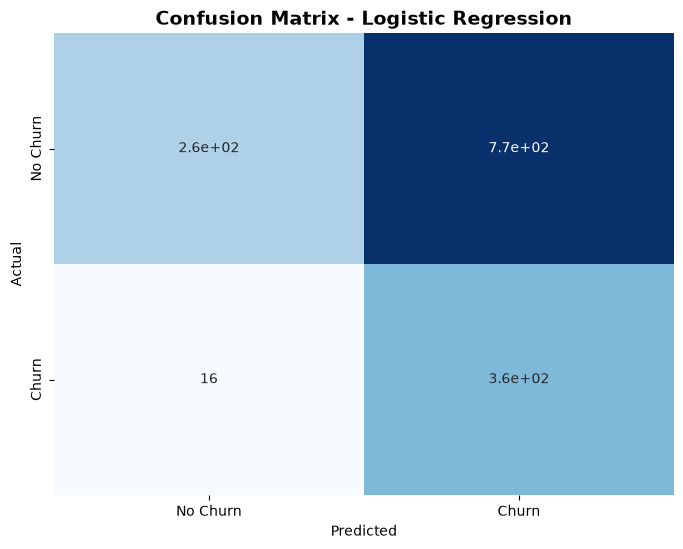

In [161]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,cmap='Blues',cbar=False,xticklabels=['No Churn','Churn'],yticklabels=['No Churn','Churn'])

plt.title('Confusion Matrix - Logistic Regression', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')

In [162]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.94      0.25      0.40      1035
           1       0.32      0.96      0.48       374

    accuracy                           0.44      1409
   macro avg       0.63      0.61      0.44      1409
weighted avg       0.78      0.44      0.42      1409



In [163]:
rf = RandomForestClassifier(random_state=42)
rf_params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

forest_model = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_params,
    n_iter=20,
    scoring='roc_auc',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)
forest_model.fit(x_train_balanced, y_train_balanced)
print("Best Parameters:", forest_model.best_params_)
print("Best CV Score:", forest_model.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None}
Best CV Score: 0.922468465300225


In [164]:
y_pred = forest_model.predict(x_test)
y_train_pred = forest_model.predict(x_train)

In [165]:
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_pred)
print('Training Accuracy', train_acc)
print('Test Accuracy', test_acc)

Training Accuracy 0.9447994320198793
Test Accuracy 0.7899219304471257


In [166]:
print(f"Precison:{precision_score(y_test,y_pred)}")
print(f"Recall:{recall_score(y_test,y_pred)}")
print(f"F1 Score:{f1_score(y_test,y_pred)}")

Precison:0.6089385474860335
Recall:0.5828877005347594
F1 Score:0.5956284153005464


Text(0.5, 36.38563368055554, 'Predicted')

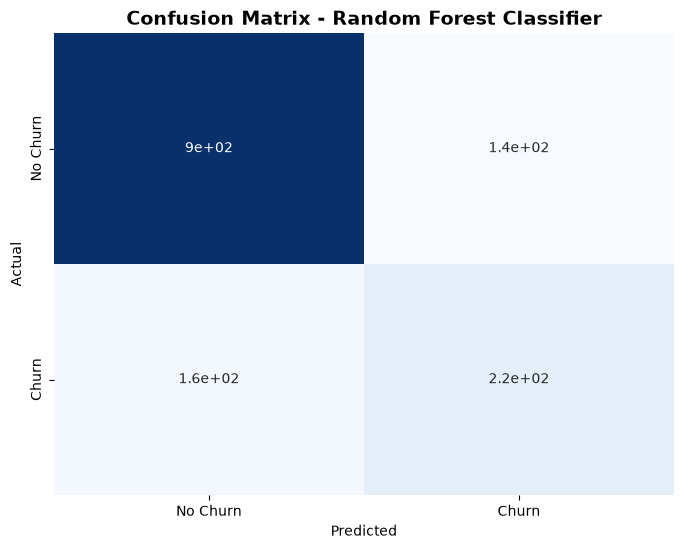

In [167]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,cmap='Blues',cbar=False,xticklabels=['No Churn','Churn'],yticklabels=['No Churn','Churn'])

plt.title('Confusion Matrix - Random Forest Classifier', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')

In [168]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.85      0.86      0.86      1035
           1       0.61      0.58      0.60       374

    accuracy                           0.79      1409
   macro avg       0.73      0.72      0.73      1409
weighted avg       0.79      0.79      0.79      1409



In [169]:
xgb_ = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1, 0.2],
    'min_child_weight': [1, 3, 5]
}

xgb_model = RandomizedSearchCV(
    estimator=xgb_,
    param_distributions=xgb_params,
    n_iter=20,
    scoring='roc_auc',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(x_train_balanced, y_train_balanced)

print("Best Parameters:", xgb_model.best_params_)
print("Best CV Score:", xgb_model.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


Best Parameters: {'subsample': 1.0, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.8}
Best CV Score: 0.9246560693518869


In [170]:
y_pred = xgb_model.predict(x_test)
y_train_pred = xgb_model.predict(x_train)

In [171]:
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_pred)
print('Training Accuracy', train_acc)
print('Test Accuracy', test_acc)

Training Accuracy 0.9282925097621584
Test Accuracy 0.7842441447835344


In [172]:
print(f"Precison:{precision_score(y_test,y_pred)}")
print(f"Recall:{recall_score(y_test,y_pred)}")
print(f"F1 Score:{f1_score(y_test,y_pred)}")

Precison:0.6023391812865497
Recall:0.5508021390374331
F1 Score:0.5754189944134078


Text(0.5, 36.38563368055554, 'Predicted')

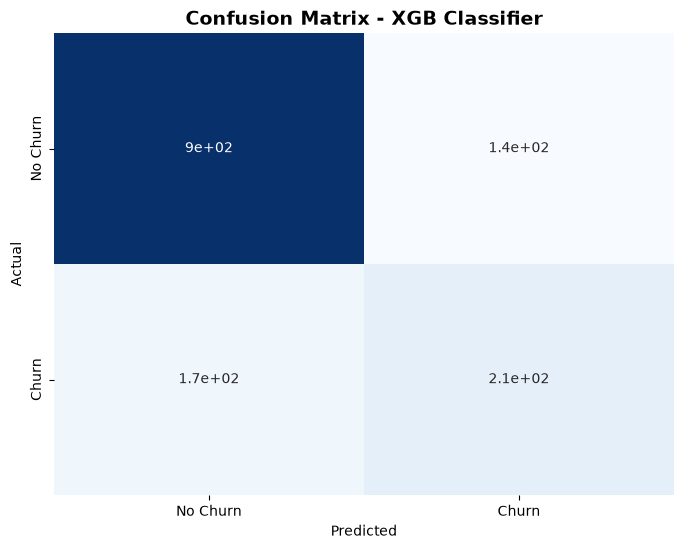

In [173]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,cmap='Blues',cbar=False,xticklabels=['No Churn','Churn'],yticklabels=['No Churn','Churn'])

plt.title('Confusion Matrix - XGB Classifier', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')

Text(0.5, 1.0, 'Feature Importance')

<Figure size 500x800 with 0 Axes>

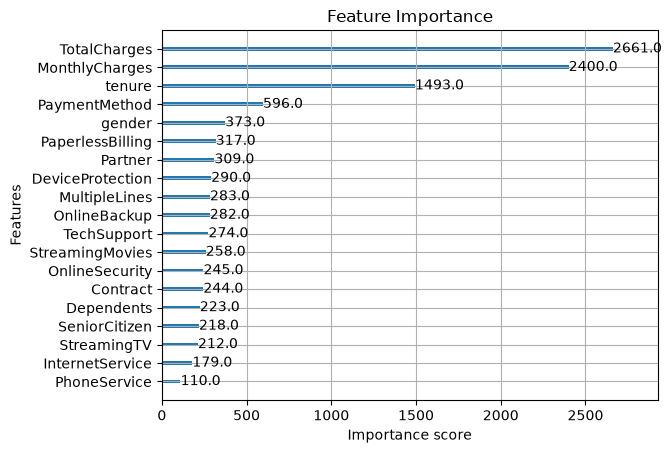

In [175]:
best_xgb = xgb_model.best_estimator_

plt.figure(figsize=(5,8))
xgb.plot_importance(best_xgb.get_booster())
plt.title("Feature Importance")

In [176]:
y_prob_lr = logreg.predict_proba(x_test_s)[:, 1]
y_prob_rf = forest_model.predict_proba(x_test)[:, 1]
y_prob_xgb = xgb_model.predict_proba(x_test)[:, 1]

c:\Users\neha2\OneDrive\Documents\Programming\ML_Projects\Customer Churn Predictor\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [177]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

In [178]:
auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_rf = roc_auc_score(y_test, y_prob_rf)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

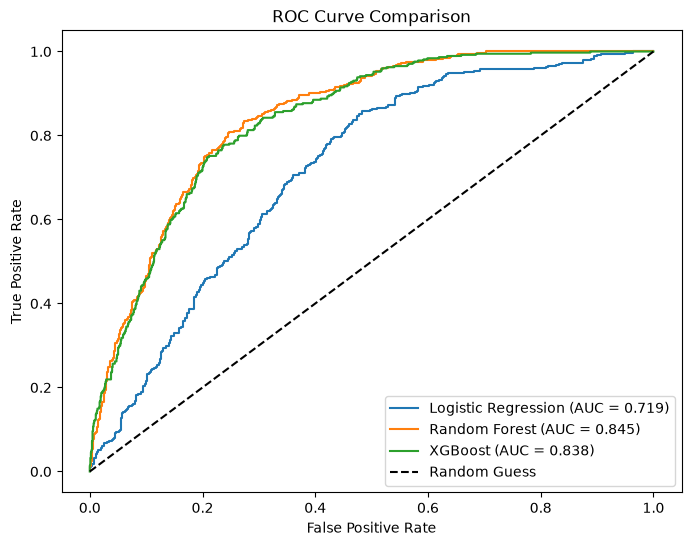

In [179]:
plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr,
         label=f'Logistic Regression (AUC = {auc_lr:.3f})')

plt.plot(fpr_rf, tpr_rf,
         label=f'Random Forest (AUC = {auc_rf:.3f})')

plt.plot(fpr_xgb, tpr_xgb,
         label=f'XGBoost (AUC = {auc_xgb:.3f})')

plt.plot([0,1], [0,1], 'k--', label='Random Guess')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc='lower right')

In [180]:
joblib.dump(forest_model.best_estimator_, 'customer_churn_model.pkl')
joblib.dump(encoders, 'churn_encoders.pkl')

['churn_encoders.pkl']